<a href="https://colab.research.google.com/github/alexsandoval05/Revenue-sustainability-Chrysal/blob/main/chrysal_profit_sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Análisis de utilidades de implementación de proyectos de sostenibilidad en Chrysal**
OBJETIVO: Definir rentabilidad anual en la implementación de proyectos de sostenibilidad y revisar si la inversion esta generando mayores ingresos.

## 1. 🧩 **Cargar y Explorar - Visión General**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales = pd.read_csv("/content/Tabla1_Chrysal_Sustainability.csv")
marketing = pd.read_csv("/content/Tabla2_Marketing_Campaign.csv")
costs = pd.read_csv("/content/Tabla3_Costs.csv")

In [2]:
sales_clean = sales.copy()
marketing_clean = marketing.copy()
costs_clean = costs.copy()

In [3]:
sales_clean.head()

,Sales_order_number,Date,Country,Product_reference,Campaign_ID,Category_product,Sales_revenue_USD,Production_cost_USD,Customer_ID
0,SO-000001,2024-02-01,Holanda,Chrysal Grow X,4,Fungicida,127316.56,57858.21,1
1,SO-000002,2025-01-01,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2
2,SO-000003,2022-05-01,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3
3,SO-000004,2024-05-01,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4
4,SO-000005,2024-04-01,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5


In [4]:
sales_clean["Date"] = pd.to_datetime(sales_clean["Date"], errors="coerce", utc=True)
sales_clean["Year"]  = sales_clean["Date"].dt.year
sales_clean["Month"] = sales_clean["Date"].dt.month
sales_clean.head()

,Sales_order_number,Date,Country,Product_reference,Campaign_ID,Category_product,Sales_revenue_USD,Production_cost_USD,Customer_ID,Year,Month
0,SO-000001,2024-02-01 00:00:00+00:00,Holanda,Chrysal Grow X,4,Fungicida,127316.56,57858.21,1,2024,2
1,SO-000002,2025-01-01 00:00:00+00:00,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2,2025,1
2,SO-000003,2022-05-01 00:00:00+00:00,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3,2022,5
3,SO-000004,2024-05-01 00:00:00+00:00,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4,2024,5
4,SO-000005,2024-04-01 00:00:00+00:00,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5,2024,4


In [5]:
sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Sales_order_number   700 non-null    object             
 1   Date                 700 non-null    datetime64[ns, UTC]
 2   Country              700 non-null    object             
 3   Product_reference    700 non-null    object             
 4   Campaign_ID          700 non-null    int64              
 5   Category_product     700 non-null    object             
 6   Sales_revenue_USD    630 non-null    float64            
 7   Production_cost_USD  700 non-null    float64            
 8   Customer_ID          700 non-null    int64              
 9   Year                 700 non-null    int32              
 10  Month                700 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(2), int32(2), int64(2), object(4)
memory usage: 5

In [6]:
sales_clean.nunique()

,0
Sales_order_number,700
Date,20
Country,4
Product_reference,5
Campaign_ID,4
Category_product,5
Sales_revenue_USD,630
Production_cost_USD,700
Customer_ID,700
Year,4


### **CONCLUSIONES:**

- Se evidencio 70 nulos en "Sales_revenue_USD" que corresponde al 100% de nulos, por tal razon debemos hacer pruebas de verificacion para saber como manejarlos.

- No se evidencian "sales_order_number" repetidas,  ya que son 700 registos y 700 datos unicos.

In [7]:
marketing_clean.head()

,Marketing_cost,Campaign_ID,Marketing_campaign_type
0,11000.0,4,Social Media
1,3000.0,3,Influencers Agro
2,11000.0,4,Social Media
3,3000.0,3,Influencers Agro
4,60000.0,2,Field Campaign


In [8]:
marketing_clean["Marketing_campaign_type"].value_counts()

,count
Marketing_campaign_type,
Social Media,2
Influencers Agro,2
Field Campaign,2
Email Marketing,2


In [9]:
marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marketing_cost           8 non-null      float64
 1   Campaign_ID              8 non-null      int64  
 2   Marketing_campaign_type  8 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes


In [10]:
costs_clean.head()

,Sales_order_number,Product_reference,Production_cost,Waste_kg,Disposal_waste_cost
0,SO-000001,Chrysal Grow X,57858.21,750.32,375.160
1,SO-000002,Chrysal Flora F,18200.66,209.94,104.970
2,SO-000003,Chrysal Flora F,101783.75,882.49,441.245
3,SO-000004,Chrysal Flora F,73680.46,982.56,491.280
4,SO-000005,Chrysal Grow X,78617.18,582.48,291.240


In [11]:
costs_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    object 
 1   Product_reference    700 non-null    object 
 2   Production_cost      700 non-null    float64
 3   Waste_kg             665 non-null    float64
 4   Disposal_waste_cost  665 non-null    float64
dtypes: float64(3), object(2)
memory usage: 27.5+ KB


In [12]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Production_cost,700
Waste_kg,664
Disposal_waste_cost,664


## **1.2 🧩 Identificación de problemas de calidad de datos**
Calcule la cantidad de vacios en "sales" y "costs"

In [13]:
sales_clean.isna().sum()
print('Porcentaje de nulos',sales_clean.isna().sum())
print('Porcentaje de nulos',sales_clean.isna().mean())

Porcentaje de nulos Sales_order_number      0
Date                    0
Country                 0
Product_reference       0
Campaign_ID             0
Category_product        0
Sales_revenue_USD      70
Production_cost_USD     0
Customer_ID             0
Year                    0
Month                   0
dtype: int64
Porcentaje de nulos Sales_order_number     0.0
Date                   0.0
Country                0.0
Product_reference      0.0
Campaign_ID            0.0
Category_product       0.0
Sales_revenue_USD      0.1
Production_cost_USD    0.0
Customer_ID            0.0
Year                   0.0
Month                  0.0
dtype: float64


In [14]:
costs_clean.isna().sum()
print('Porcentaje de nulos',costs_clean.isna().sum())
print('Porcentaje de nulos',costs_clean.isna().mean())


Porcentaje de nulos Sales_order_number      0
Product_reference       0
Production_cost         0
Waste_kg               35
Disposal_waste_cost    35
dtype: int64
Porcentaje de nulos Sales_order_number     0.00
Product_reference      0.00
Production_cost        0.00
Waste_kg               0.05
Disposal_waste_cost    0.05
dtype: float64


In [15]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Production_cost,700
Waste_kg,664
Disposal_waste_cost,664


# **2- Estadistica Descriptiva**

In [16]:
print("sales",sales_clean.describe())
print("marketing",marketing_clean.describe())
print("costs",costs_clean.describe())

sales        Campaign_ID  Sales_revenue_USD  Production_cost_USD  Customer_ID  \
count   700.000000         630.000000           700.000000    700.00000   
mean      2.537143       94651.089063         51202.551386    350.50000   
std       1.130937       51459.167383         29005.844290    202.21688   
min       1.000000        4838.780000          2103.090000      1.00000   
25%       2.000000       52970.632500         27831.665000    175.75000   
50%       3.000000       95928.995000         51334.860000    350.50000   
75%       4.000000      134256.020000         73362.980000    525.25000   
max       4.000000      222096.760000        135566.840000    700.00000   

              Year       Month  
count   700.000000  700.000000  
mean   2023.560000    2.997143  
std       1.136267    1.447208  
min    2022.000000    1.000000  
25%    2023.000000    2.000000  
50%    2024.000000    3.000000  
75%    2025.000000    4.000000  
max    2025.000000    5.000000  
marketing        Mark

**HALLAZGOS:**
- **Sales Revenue USD**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es el doble del "75%"
- **Production_cost**: Es posible sistribucion normal pero se debe descartar con histograma
- **Waste_kg** y **Disposal_waste_cost**: Posible distribucion con sesgos o "outlier"a la izquierda ya que el min es 10 veces menor que el "25%"

## **2.1 Analisis complementario**
### **2.1.1 Realice pruebas de comparacion de media y mediana** para entender la tendencia de "Sales_revenue_USD" y "production_costs" en tabla de "sales_clean"

In [17]:
columnas_numericas_sales = sales_clean[['Sales_revenue_USD', 'Production_cost_USD']]

for col in columnas_numericas_sales:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", columnas_numericas_sales[col].mean(),"- Mediana:", columnas_numericas_sales[col].median())
    print()

Sales_revenue_USD
Promedio 94651.08906349207 - Mediana: 95928.995

Production_cost_USD
Promedio 51202.55138571429 - Mediana: 51334.86



## **CONCLUSIONES:**

- Se evidencia ligera tendencia de sesgo a la derecha para "Sales_revenue_USD" por tal razon los datos vacios se reemplazaran por la mediana.



### 2.1.3 Realice evaluacion **agrupando por año y pais** para revisar dominancia en la columna "Sales_revenue_USD"

In [18]:
resumen_pais = (
    sales_clean
    .groupby(['Country', 'Year'])
    .agg(
        avg_sales=('Sales_revenue_USD', 'mean'),
        count_sales=('Sales_revenue_USD', 'count'),
        desv_sales=('Sales_revenue_USD', 'std'),
        min_sales=('Sales_revenue_USD', 'min'),
        max_sales=('Sales_revenue_USD', 'max'),

    )
    .reset_index()
)
resumen_pais

,Country,Year,avg_sales,count_sales,desv_sales,min_sales,max_sales
0,Colombia,2022,89852.641515,33,50148.873551,13230.36,176983.83
1,Colombia,2023,89426.186154,39,51614.766564,13064.64,180848.44
2,Colombia,2024,112120.543158,38,57058.053383,6342.83,194085.76
3,Colombia,2025,95596.203077,39,55196.544372,8086.54,195064.00
4,Ecuador,2022,93842.490769,39,58125.263618,10992.52,222096.76
5,Ecuador,2023,94175.773261,46,53813.524831,5427.42,217312.03
6,Ecuador,2024,95799.619333,45,45223.315753,14898.64,188013.75
7,Ecuador,2025,91342.477778,45,54085.669181,5719.70,190712.14
8,Holanda,2022,92638.347179,39,47829.785241,10447.40,181871.75
9,Holanda,2023,93676.323429,35,54410.473785,4838.78,213030.15


**CONCLUSIONES**:

No se evidencia dominancia de tendencia por año y pais.

In [19]:
columnas_categoricas_1 = sales_clean[['Country','Product_reference','Category_product']]
columnas_categoricas_2 = marketing_clean[['Marketing_campaign_type']]

print(columnas_categoricas_1.describe())
print(columnas_categoricas_2.describe())


        Country Product_reference Category_product
count       700               700              700
unique        4                 5                5
top     Ecuador   Chrysal Flora F      Nutricional
freq        188               154              157
       Marketing_campaign_type
count                        8
unique                       4
top               Social Media
freq                         2


In [20]:
for col in columnas_categoricas_1:
    print(col)
    print(sales_clean[col].value_counts())
    print()

Country
Country
Ecuador     188
Colombia    177
Holanda     175
Kenya       160
Name: count, dtype: int64

Product_reference
Product_reference
Chrysal Flora F      154
Chrysal Root R       149
Chrysal Protect Y    148
Chrysal Grow X       139
Chrysal Boost Z      110
Name: count, dtype: int64

Category_product
Category_product
Nutricional                 157
Fertilizante                145
Insecticida                 140
Regulador de crecimiento    133
Fungicida                   125
Name: count, dtype: int64



In [21]:
print(marketing_clean["Marketing_campaign_type"].value_counts())

Marketing_campaign_type
Social Media        2
Influencers Agro    2
Field Campaign      2
Email Marketing     2
Name: count, dtype: int64


**CONCLUSION DE ANALISIS:**




De acuerdo a este conteo de columnas **categoricas dominantes**  **NO** se evidencia una afectacion especifica por alguna categoria evaluada.

## **3- Visualizacion Diagnóstica**

In [22]:
sales_paises = sales_clean[(sales_clean['Country']=='Colombia') |
                  (sales_clean['Country']=='Holanda') |
                  (sales_clean['Country']=='Kenya') |
                  (sales_clean['Country']=='Ecuador')
]
sales_paises

,Sales_order_number,Date,Country,Product_reference,Campaign_ID,Category_product,Sales_revenue_USD,Production_cost_USD,Customer_ID,Year,Month
0,SO-000001,2024-02-01 00:00:00+00:00,Holanda,Chrysal Grow X,4,Fungicida,127316.56,57858.21,1,2024,2
1,SO-000002,2025-01-01 00:00:00+00:00,Kenya,Chrysal Flora F,3,Nutricional,28100.09,18200.66,2,2025,1
2,SO-000003,2022-05-01 00:00:00+00:00,Ecuador,Chrysal Flora F,4,Insecticida,222096.76,101783.75,3,2022,5
3,SO-000004,2024-05-01 00:00:00+00:00,Kenya,Chrysal Flora F,3,Nutricional,114488.78,73680.46,4,2024,5
4,SO-000005,2024-04-01 00:00:00+00:00,Colombia,Chrysal Grow X,2,Insecticida,140394.64,78617.18,5,2024,4
...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,2025-02-01 00:00:00+00:00,Colombia,Chrysal Boost Z,3,Fertilizante,134575.02,74479.46,696,2025,2
696,SO-000697,2024-01-01 00:00:00+00:00,Holanda,Chrysal Grow X,2,Fertilizante,137243.67,85041.16,697,2024,1
697,SO-000698,2023-05-01 00:00:00+00:00,Ecuador,Chrysal Root R,3,Nutricional,70017.12,41102.49,698,2023,5
698,SO-000699,2023-03-01 00:00:00+00:00,Colombia,Chrysal Flora F,1,Insecticida,180848.44,91872.60,699,2023,3


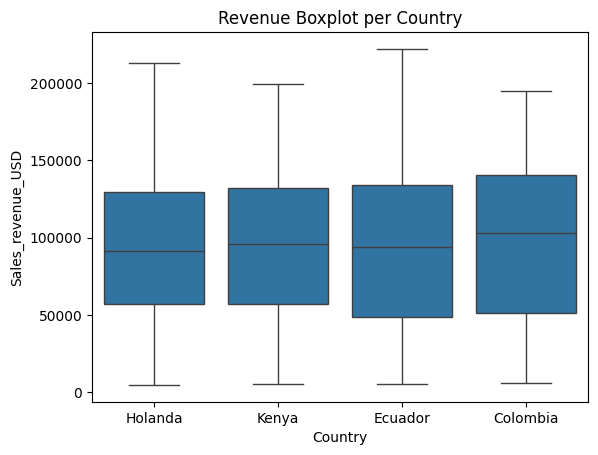

In [23]:
sns.boxplot(data=sales_paises, x="Country", y="Sales_revenue_USD")
plt.title(f'Revenue Boxplot per Country')
plt.show()


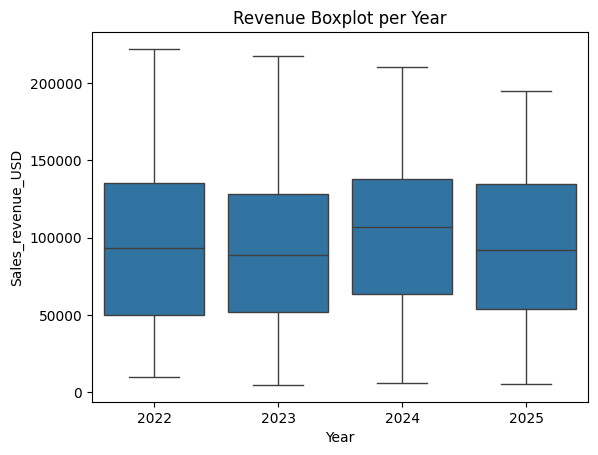

In [24]:
sns.boxplot(data=sales_paises, x="Year", y="Sales_revenue_USD")
plt.title(f'Revenue Boxplot per Year')
plt.show()


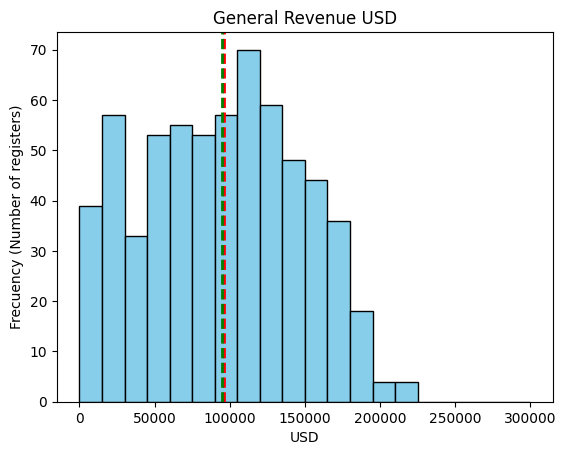

In [25]:

plt.hist(sales_clean['Sales_revenue_USD'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['Sales_revenue_USD'].median()
average_sales = sales_clean['Sales_revenue_USD'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Revenue USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

##4- Identificacion formal de Outliers

##5 - Limpieza automatica por pipeline

In [26]:
sales_clean['Sales_revenue_USD'] = sales_clean['Sales_revenue_USD'].fillna(sales_clean['Sales_revenue_USD'].median())
print('Porcentaje de nulos',sales_clean.isna().sum())

Porcentaje de nulos Sales_order_number     0
Date                   0
Country                0
Product_reference      0
Campaign_ID            0
Category_product       0
Sales_revenue_USD      0
Production_cost_USD    0
Customer_ID            0
Year                   0
Month                  0
dtype: int64


##7- Unificación tabla de interes para calculos de % Profit y % ROI.

- Agregue a la tabla de "Sales_clean" la tabla de "Costs"

In [27]:
sales_clean_small = sales_clean[['Sales_order_number','Sales_revenue_USD','Year','Production_cost_USD','Country','Product_reference']]

sales_final = pd.merge(sales_clean_small, costs_clean, on=['Sales_order_number'], how='left')

sales_final.head()

,Sales_order_number,Sales_revenue_USD,Year,Production_cost_USD,Country,Product_reference_x,Product_reference_y,Production_cost,Waste_kg,Disposal_waste_cost
0,SO-000001,127316.56,2024,57858.21,Holanda,Chrysal Grow X,Chrysal Grow X,57858.21,750.32,375.160
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,18200.66,209.94,104.970
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,101783.75,882.49,441.245
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,73680.46,982.56,491.280
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,78617.18,582.48,291.240


In [28]:
sales_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    object 
 1   Sales_revenue_USD    700 non-null    float64
 2   Year                 700 non-null    int32  
 3   Production_cost_USD  700 non-null    float64
 4   Country              700 non-null    object 
 5   Product_reference_x  700 non-null    object 
 6   Product_reference_y  700 non-null    object 
 7   Production_cost      700 non-null    float64
 8   Waste_kg             665 non-null    float64
 9   Disposal_waste_cost  665 non-null    float64
dtypes: float64(5), int32(1), object(4)
memory usage: 52.1+ KB


In [40]:
sales_final['costo_total'] = sales_final['Production_cost_USD'] + sales_final['Disposal_waste_cost']
sales_final['gross_profit'] = sales_final['Sales_revenue_USD'] - sales_final['costo_total']
sales_final['margin_pct'] = (sales_final['gross_profit']) *100 / sales_final['Sales_revenue_USD']
sales_final

,Sales_order_number,Sales_revenue_USD,Year,Production_cost_USD,Country,Product_reference_x,Product_reference_y,Production_cost,Waste_kg,Disposal_waste_cost,costo_total,margin_pct,gross_profit
0,SO-000001,127316.56,2024,57858.21,Holanda,Chrysal Grow X,Chrysal Grow X,57858.21,750.32,375.160,58233.370,54.260962,69083.190
1,SO-000002,28100.09,2025,18200.66,Kenya,Chrysal Flora F,Chrysal Flora F,18200.66,209.94,104.970,18305.630,34.855618,9794.460
2,SO-000003,222096.76,2022,101783.75,Ecuador,Chrysal Flora F,Chrysal Flora F,101783.75,882.49,441.245,102224.995,53.972766,119871.765
3,SO-000004,114488.78,2024,73680.46,Kenya,Chrysal Flora F,Chrysal Flora F,73680.46,982.56,491.280,74171.740,35.214839,40317.040
4,SO-000005,140394.64,2024,78617.18,Colombia,Chrysal Grow X,Chrysal Grow X,78617.18,582.48,291.240,78908.420,43.795276,61486.220
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,134575.02,2025,74479.46,Colombia,Chrysal Boost Z,Chrysal Boost Z,74479.46,605.26,302.630,74782.090,44.430928,59792.930
696,SO-000697,137243.67,2024,85041.16,Holanda,Chrysal Grow X,Chrysal Grow X,85041.16,669.30,334.650,85375.810,37.792534,51867.860
697,SO-000698,70017.12,2023,41102.49,Ecuador,Chrysal Root R,Chrysal Root R,41102.49,846.95,423.475,41525.965,40.691698,28491.155
698,SO-000699,180848.44,2023,91872.60,Colombia,Chrysal Flora F,Chrysal Flora F,91872.60,2069.15,1034.575,92907.175,48.627052,87941.265


In [43]:
profit_percent_year = (
    sales_final
    .groupby(['Year'])
    .agg(
        avg_profit=('margin_pct', 'mean'),
        gross_profit=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_year

,Year,avg_profit,gross_profit
0,2022,45.062355,7119.852025
1,2023,45.202596,7413.225780
2,2024,45.146432,7087.989820
3,2025,44.238950,8228.444769


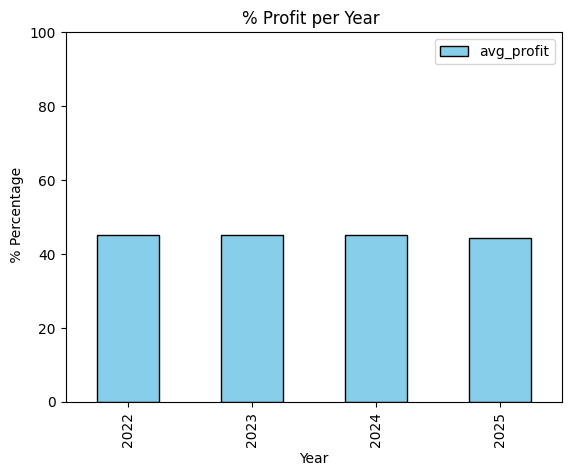

In [52]:
profit_percent_year.plot(x='Year', y=['avg_profit'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('% Profit per Year ')
plt.ylabel(' % Percentage')
plt.ylim(0,100)
plt.show()

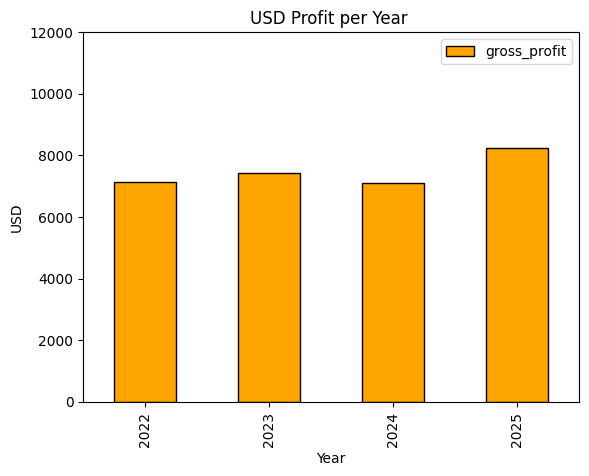

In [54]:
profit_percent_year.plot(x='Year', y=['gross_profit'], kind='bar', color='orange', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Year ')
plt.ylabel('USD')
plt.ylim(0,12000)
plt.show()